In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

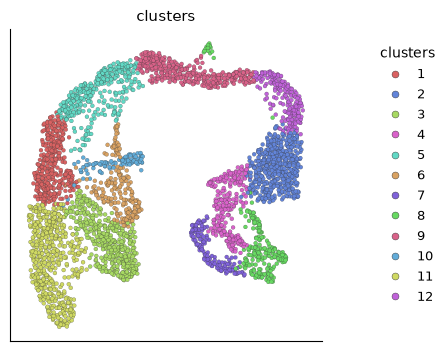

In [2]:
ds.plots.embedding(
    run=analysis_run,
    color_by="clusters",
)

In [3]:
cell_cycle_ref = ds.run_cell_cycle_scoring(analysis_run["analysis_cell_selection"])
cell_cycle_values = ds.load_artifact(cell_cycle_ref)
s_score = np.asarray(cell_cycle_values["s_score"][:])
g2m_score = np.asarray(cell_cycle_values["g2m_score"][:])
phase = np.asarray(cell_cycle_values["phase"][:]).astype(str)

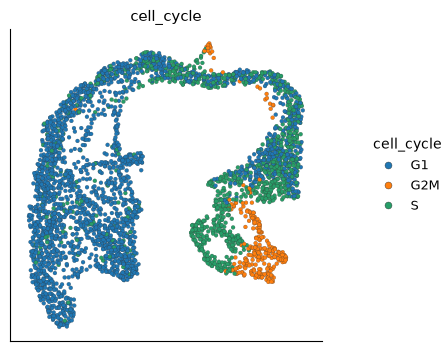

In [4]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=cell_cycle_ref,
)

In [5]:
pd.crosstab(analysis_run.cells.fetch("clusters"), phase, normalize="index")

col_0,G1,G2M,S
row_0,,,
1,0.912807,0.000000,0.087193
2,0.410156,0.005859,0.583984
3,0.934924,0.000000,0.065076
4,0.110169,0.067797,0.822034
5,0.825215,0.005731,0.169054
6,0.924623,0.000000,0.075377
7,0.000000,0.110345,0.889655
8,0.000000,0.977477,0.022523
9,0.498674,0.007958,0.493369


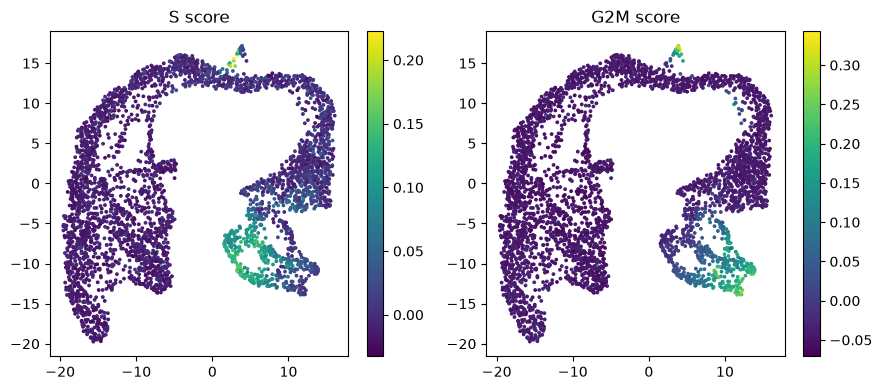

In [6]:
umap = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, values, title in (
    (axes[0], s_score, "S score"),
    (axes[1], g2m_score, "G2M score"),
):
    points = axis.scatter(umap["umap_1"], umap["umap_2"], c=values, s=3)
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure

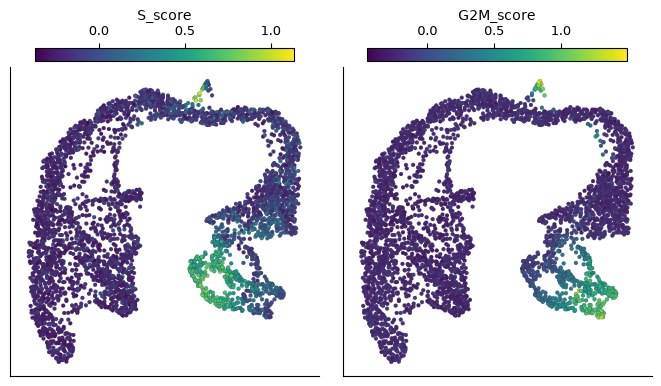

In [7]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by=["S_score", "G2M_score"],
    n_columns=2,
)

In [8]:
pd.Series(
    {
        "S": np.corrcoef(s_score, ds.cells.fetch("S_score"))[0, 1],
        "G2M": np.corrcoef(g2m_score, ds.cells.fetch("G2M_score"))[0, 1],
    },
    name="Pearson r",
)

S      0.979234
G2M    0.983716
Name: Pearson r, dtype: float64